In [66]:
import pandas as pd
import numpy as np
import seaborn as sns

In [67]:
df = pd.read_csv("diabetes_dataset.csv")

In [68]:
df.head()

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0


In [69]:
df.shape

(100000, 16)

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  100000 non-null  int64  
 1   gender                100000 non-null  object 
 2   age                   100000 non-null  float64
 3   location              100000 non-null  object 
 4   race:AfricanAmerican  100000 non-null  int64  
 5   race:Asian            100000 non-null  int64  
 6   race:Caucasian        100000 non-null  int64  
 7   race:Hispanic         100000 non-null  int64  
 8   race:Other            100000 non-null  int64  
 9   hypertension          100000 non-null  int64  
 10  heart_disease         100000 non-null  int64  
 11  smoking_history       100000 non-null  object 
 12  bmi                   100000 non-null  float64
 13  hbA1c_level           100000 non-null  float64
 14  blood_glucose_level   100000 non-null  int64  
 15  d

In [71]:
df.isnull().sum()


year                    0
gender                  0
age                     0
location                0
race:AfricanAmerican    0
race:Asian              0
race:Caucasian          0
race:Hispanic           0
race:Other              0
hypertension            0
heart_disease           0
smoking_history         0
bmi                     0
hbA1c_level             0
blood_glucose_level     0
diabetes                0
dtype: int64

In [72]:
df.drop(columns=["year","location","race:AfricanAmerican","race:Asian","race:Caucasian","race:Hispanic","race:Other"],inplace=True)

In [73]:
for cols in df.columns:
    print(f"{cols}: {df[cols].unique()}\n")

gender: ['Female' 'Male' 'Other']

age: [32.   29.   18.   41.   52.   66.   49.   15.   51.   42.   53.    3.
 40.   64.   23.    2.   80.   12.   50.   69.   75.   72.   46.   47.
 14.   24.   55.   13.   31.   38.   67.   61.   79.    8.   11.   71.
 25.    5.    6.   28.    4.   54.   43.   65.    7.   48.    1.32 63.
 59.   39.   19.   62.   45.   44.   73.   10.   26.   22.   68.   57.
  0.8  60.   30.   58.   77.   56.   37.   20.   21.    9.   36.   35.
  1.   17.   78.   16.    0.48 27.   70.    0.64  1.56  1.72 74.    1.16
 33.   34.   76.    1.08  0.16  1.24  0.08  0.72  0.32  0.24  0.4   1.64
  1.88  1.4   1.48  0.56  0.88  1.8 ]

hypertension: [0 1]

heart_disease: [0 1]

smoking_history: ['never' 'not current' 'current' 'No Info' 'ever' 'former']

bmi: [27.32 19.95 23.76 ... 59.91 50.8  10.34]

hbA1c_level: [5.  4.8 4.  6.5 5.7 6.  6.6 3.5 8.2 6.2 6.1 8.8 7.5 6.8 5.8 7.  4.5 9. ]

blood_glucose_level: [100  90 160 159  80 155 200 126 140 130 158 145 220  85 280 260 240 30

In [74]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

In [75]:
smoking_order = [['never','not current','current','No Info','ever','former']]
oe = OrdinalEncoder(categories=smoking_order)
df['smoking_history'] = oe.fit_transform(df[['smoking_history']])

In [76]:
gender_map = {"Male":0, "Female":1, "Other":2}
df['gender'] = df['gender'].map(gender_map).fillna(2).astype(int)

In [77]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,1,32.0,0,0,0.0,27.32,5.0,100,0
1,1,29.0,0,0,0.0,19.95,5.0,90,0
2,0,18.0,0,0,0.0,23.76,4.8,160,0
3,0,41.0,0,0,0.0,27.32,4.0,159,0
4,1,52.0,0,0,0.0,23.75,6.5,90,0


In [78]:
df.sample(20)

,gender,age,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
86478,0,50.0,0,0,0.0,27.32,6.6,126,0
29856,1,34.0,0,0,0.0,41.50,6.6,158,0
33798,0,5.0,0,0,3.0,15.26,6.0,158,0
68621,1,20.0,0,0,3.0,27.32,6.1,130,0
54908,0,30.0,0,0,3.0,21.12,5.8,85,0
56412,0,44.0,0,0,3.0,27.32,4.5,140,0
66844,1,80.0,1,0,1.0,26.23,5.8,130,0
26508,0,57.0,0,0,3.0,23.19,4.8,100,0
45002,0,7.0,0,0,3.0,15.01,6.2,159,0
30118,1,75.0,1,0,4.0,37.04,5.8,158,0


In [79]:
df.corr()

,gender,age,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
gender,1.000000,0.030061,-0.014517,-0.077933,-0.101103,0.023009,-0.020086,-0.017165,-0.037752
age,0.030061,1.000000,0.251171,0.233354,0.001760,0.337396,0.101354,0.110672,0.258008
hypertension,-0.014517,0.251171,1.000000,0.121262,-0.010940,0.147666,0.080939,0.084429,0.197823
heart_disease,-0.077933,0.233354,0.121262,1.000000,0.060360,0.061198,0.067589,0.070066,0.171727
smoking_history,-0.101103,0.001760,-0.010940,0.060360,1.000000,-0.049718,0.001020,-0.000465,0.004060
bmi,0.023009,0.337396,0.147666,0.061198,-0.049718,1.000000,0.082997,0.091261,0.214357
hbA1c_level,-0.020086,0.101354,0.080939,0.067589,0.001020,0.082997,1.000000,0.166733,0.400660
blood_glucose_level,-0.017165,0.110672,0.084429,0.070066,-0.000465,0.091261,0.166733,1.000000,0.419558
diabetes,-0.037752,0.258008,0.197823,0.171727,0.004060,0.214357,0.400660,0.419558,1.000000


In [80]:
import matplotlib.pyplot as plt

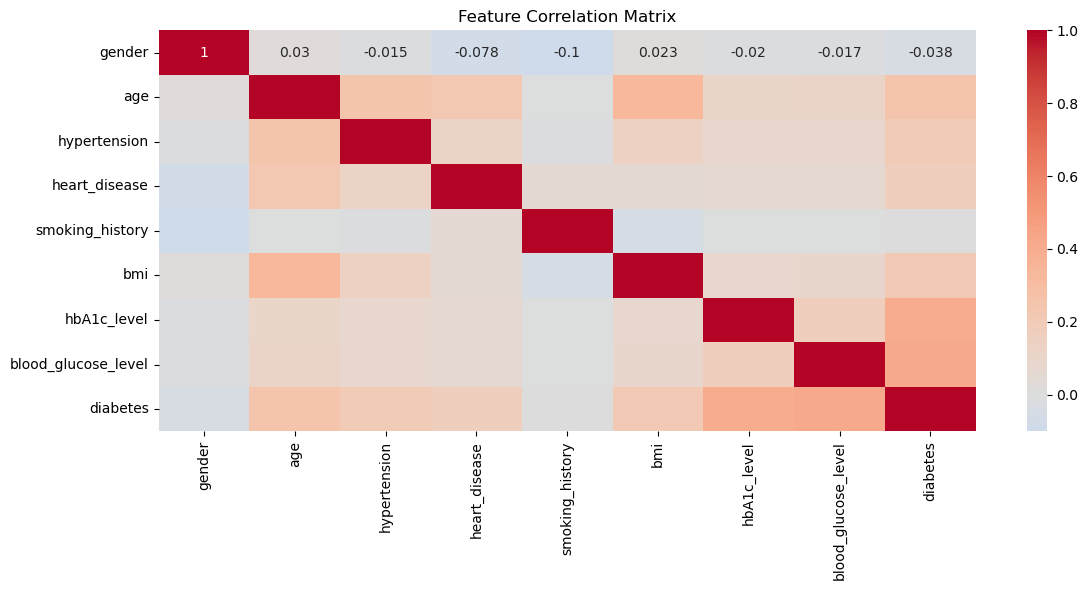

In [112]:
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [82]:
X = df.drop(columns=['diabetes'])
y = df['diabetes']

In [83]:
from sklearn.model_selection import train_test_split

In [84]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [85]:
from sklearn.preprocessing import StandardScaler

In [86]:
scaler = StandardScaler()

In [87]:
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [88]:
print(f"Train: {X_train_s.shape}, Test: {X_test_s.shape}")

Train: (70000, 8), Test: (30000, 8)


In [89]:
from imblearn.over_sampling import SMOTE

In [90]:
sm = SMOTE(random_state=42,sampling_strategy=0.5)

In [91]:
X_train_smote,y_train_smote = sm.fit_resample(X_train_s,y_train)

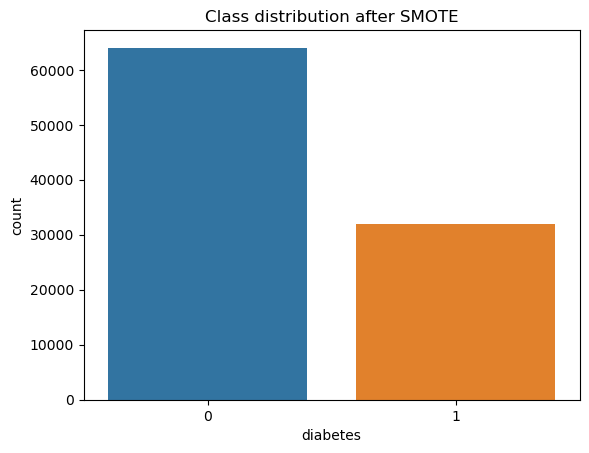

In [92]:
sns.countplot(x=y_train_smote)
plt.title("Class distribution after SMOTE")
plt.show()

In [93]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

In [94]:
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score

In [105]:
from sklearn.metrics import roc_auc_score, average_precision_score

In [119]:
def find_best_model(X_train,y_train,X_test,y_test):
    algos = {
        'Logistic Regression' : {
            "model" : LogisticRegression(),
            "params" : {
                "C":[1,5,10,15],
                "class_weight":[{0:1,1:5},{0:1,1:10}],
            }
        },
        'Random Forest': {
            "model" : RandomForestClassifier(),
            "params" : {
                "n_estimators":[50,100,200],
                "max_depth":[None,10,20],
                "class_weight" : [{0:1,1:5},{0:1,1:10}]
            }
        },
        "Gradient Boosting" : {
            'model' : GradientBoostingClassifier(),
            'params' : {
                'n_estimators' : [50,100,200],
                'learning_rate' : [0.01,0.1],
                'max_depth' : [3,5,7]
            }
        }

    }


    scores = []
    total_algos = len(algos)

    for index, (algo_name, config) in enumerate(algos.items()):
        gs = GridSearchCV(config['model'], config['params'], scoring='recall', verbose=1,n_jobs=-1)
        gs.fit(X_train,y_train)
        
        # Evaluate best model
        best_model = gs.best_estimator_
        y_pred = best_model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test,y_pred)

        scores.append({
        'model': algo_name,
        'best_score': gs.best_score_,
        'best_params': gs.best_params_,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'roc_auc': roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1]),     
        'pr_auc': average_precision_score(y_test, best_model.predict_proba(X_test)[:,1])
})
    
    return pd.DataFrame(scores)

In [120]:
scores = find_best_model(X_train_smote,y_train_smote,X_test_s,y_test)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Fitting 5 folds for each of 18 candidates, totalling 90 fits


In [121]:
scores

,model,best_score,best_params,accuracy,precision,recall,roc_auc,pr_auc
0,Logistic Regression,0.975725,"{'C': 1, 'class_weight': {0: 1, 1: 10}}",0.746800,0.244929,0.969396,0.959481,0.807503
1,Random Forest,0.992283,"{'class_weight': {0: 1, 1: 10}, 'max_depth': 1...",0.790133,0.283108,0.980525,0.972175,0.847345
2,Gradient Boosting,0.930262,"{'learning_rate': 0.1, 'max_depth': 7, 'n_esti...",0.970800,0.938034,0.697933,0.976120,0.873500


In [129]:
import pprint
pprint.pprint(scores['best_params'][1])

{'class_weight': {0: 1, 1: 10}, 'max_depth': 10, 'n_estimators': 200}


In [113]:
from sklearn.metrics import confusion_matrix

In [143]:
from sklearn.metrics import ConfusionMatrixDisplay

In [134]:
lr = LogisticRegression(C=1,class_weight={0:1,1:10})

In [135]:
lr.fit(X_train_smote,y_train_smote)

LogisticRegression(C=1, class_weight={0: 1, 1: 10})

In [136]:
y_pred = lr.predict(X_test_s)

In [137]:
confusion_matrix_lr = confusion_matrix(y_test,y_pred)

In [150]:
confusion_matrix_lr

array([[19965,  7519],
       [   77,  2439]], dtype=int64)

In [138]:
rf = RandomForestClassifier( class_weight= {0: 1, 1: 10}, max_depth= 10, n_estimators= 200)

In [139]:
rf.fit(X_train_smote,y_train_smote)

RandomForestClassifier(class_weight={0: 1, 1: 10}, max_depth=10,
                       n_estimators=200)

In [140]:
y_pred = rf.predict(X_test_s)

In [141]:
confusion_matrix_rf = confusion_matrix(y_test,y_pred)

In [151]:
confusion_matrix_rf

array([[21081,  6403],
       [   45,  2471]], dtype=int64)

In [159]:
from sklearn.model_selection import cross_val_score


In [156]:
lr_best = LogisticRegression(C=1,class_weight={0:1,1:10})

cv_scores = cross_val_score(lr_best, X_train_smote, y_train_smote, cv=5, scoring='recall')

print(f"CV Recall scores : {cv_scores}")
print(f"Mean             : {cv_scores.mean():.3f}")
print(f"Std              : {cv_scores.std():.3f}")

CV Recall scores : [0.97125449 0.97938144 0.97906904 0.97750703 0.97141072]
Mean             : 0.976
Std              : 0.004


In [ ]:
rf_best = RandomForestClassifier(class_weight= {0: 1, 1: 10}, max_depth= 10, n_estimators= 200)

cv_scores = cross_val_score(rf_best, X_train_smote, y_train_smote, cv=5, scoring='recall')

print(f"CV Recall scores : {cv_scores}")
print(f"Mean             : {cv_scores.mean():.3f}")
print(f"Std              : {cv_scores.std():.3f}")

CV Recall scores : [0.98390876 0.99500156 0.99328335 0.99625117 0.99250117]
Mean             : 0.992
Std              : 0.004
